# Multipartition results with BDA, new graphs for paper

In [1]:
import matplotlib.pyplot as plt
import matplotlib
import numpy
import os
import logging, sys
import math

from radioimaging.util import util
from radioimaging.evaluation import evaluation
from radioimaging.visibility import residual
from radioimaging.visibility import weights

matplotlib.rcParams['figure.figsize'] = [6, 5]

cmap = "turbo"

breakdowns = [
    "read",
    "grid",
    "degrid",
    "deconvolve",
    "other"
]

breakdowns_parallel = [
    "read",
    "grid",
    "degrid",
    "deconvolve",
    "wait",
    "other"
]

def total_timings(timings, breakdowns):
    total = []
    
    for i, breakdown in enumerate(breakdowns):
        curr_timing = 0

        for timing in timings:
            curr_timing += timing[i]

        total.append(curr_timing)
        
    return total

pcols = ["black", "firebrick", "darkgreen", "royalblue", "darkviolet", "mediumvioletred", "darkturquoise"]

In [2]:
config = "MID"
num_partitions = [4, 6, 8, 10]
results_root = "../results/multi_partition_bda_results/"
gt = util.fromfits("../data7/SGRA_full_gt.fits")

num_mc_l1 = 5
num_mc_msc = 5

alphas_sgra = [1, 0.27, 0.177, 0.147, 0.118]
alphas_sgrb = [1, 0.267, 0.191, 0.144, 0.12]

## Read in all plottable data

### Timing data by subprocesses

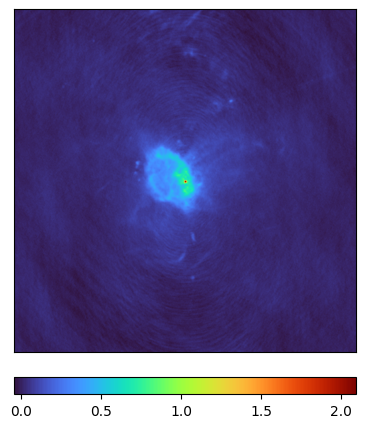

In [3]:
pl1_breakdown_data = []
pmsc_breakdown_data = []
vis_counts = []

for i in num_partitions:
    curr_pl1_breakdown = []
    curr_pmsc_breakdown = []

    curr_vis_counts = []
    for j in range(i):
        curr_pl1_breakdown.append(util.read_csv(results_root + config + "/" + str(i) + "/pl1/mc_timings_breakdown_" + str(j), separate_rows=True))
        curr_pmsc_breakdown.append(util.read_csv(results_root + config + "/" + str(i) + "/pmsc/mc_timings_breakdown_" + str(j), separate_rows=True))
        curr_vis_counts.append(int(curr_pl1_breakdown[-1][0][0]))

    vis_counts.append(max(curr_vis_counts))
    
    # mad = numpy.mean(numpy.abs(numpy.mean(numpy.array(curr_vis_counts)) - numpy.array(curr_vis_counts)))
    # print(mad / numpy.mean(numpy.array(curr_vis_counts)))
    
    pl1_breakdown_data.append(curr_pl1_breakdown)
    pmsc_breakdown_data.append(curr_pmsc_breakdown)
    
seriall1_breakdown_data = util.read_csv(results_root + config + "/10/l1/mc_timings_breakdown", separate_rows=True)
serialmsc_breakdown_data = util.read_csv(results_root + config + "/10/msc/mc_timings_breakdown", separate_rows=True)

vis_counts = [int(seriall1_breakdown_data[0][0])] + vis_counts

dirty = util.fromfits(results_root + config + "/10/l1/residual_0.fits")
util.plotNImages([dirty], [""], cmap="turbo", hide_ticks=True)

### Reconstruction wall processing time and SNR

In [4]:
seriall1_times = []
serialmsc_times = []
parallell1_times = []
parallelmsc_times = []

seriall1_times_bymc = []
serialmsc_times_bymc = []
parallell1_times_bymc = []
parallelmsc_times_bymc = []

seriall1_snrs = []
serialmsc_snrs = []
parallell1_snrs = []
parallelmsc_snrs = []

parallell1_csnrs = []
parallelmsc_csnrs = []

#### Serial

In [5]:
seriall1_sep = util.read_csv(results_root + config + "/10/l1/mc_timings")
serialmsc_sep = util.read_csv(results_root + config + "/10/msc/mc_timings")

curr_l1deconv = None
curr_mscdeconv = None

l1acc = float(seriall1_sep[0])
mscacc = float(serialmsc_sep[0])

#the first timestamp is for the calculation of the weights and psf
seriall1_times.append(l1acc)
serialmsc_times.append(mscacc)
seriall1_times_bymc.append(l1acc)
serialmsc_times_bymc.append(mscacc)
seriall1_snrs.append(0)
serialmsc_snrs.append(0)

for i in range(0, num_mc_l1):
    l1deconv = util.fromfits(results_root + config + "/10/l1/deconvolved_" + str(i) + ".fits")
    mscdeconv = util.fromfits(results_root + config + "/10/msc/deconvolved_" + str(i) + ".fits")
    
    if curr_l1deconv is None:
        curr_l1deconv = l1deconv
        curr_mscdeconv = mscdeconv
    else:
        curr_l1deconv += l1deconv
        curr_mscdeconv += mscdeconv
        
    l1acc += float(seriall1_sep[i+1])
    mscacc += float(serialmsc_sep[i+1])

    seriall1_times.append(l1acc)
    serialmsc_times.append(mscacc)
    seriall1_times_bymc.append(float(seriall1_sep[i+1]))
    serialmsc_times_bymc.append(float(serialmsc_sep[i+1]))
    
    seriall1_snrs.append(evaluation.compute_snr(gt, curr_l1deconv))
    serialmsc_snrs.append(evaluation.compute_snr(gt, curr_mscdeconv))

#### Parallel

In [6]:
for partition_config in num_partitions:
    pl1_sep = util.read_csv(results_root + config + "/" + str(partition_config) + "/pl1/mc_timings")
    pmsc_sep = util.read_csv(results_root + config + "/" + str(partition_config) + "/pmsc/mc_timings")
    
    curr_l1deconvs = [None for i in range(partition_config)]
    curr_mscdeconvs = [None for i in range(partition_config)]
    
    l1acc = float(pl1_sep[0])
    mscacc = float(pmsc_sep[0])

    curr_pl1_times = [l1acc]
    curr_pmsc_times = [mscacc]

    curr_pl1_snrs = []
    curr_pmsc_snrs = []

    curr_pl1_times_bymc = [l1acc]
    curr_pmsc_times_bymc = [mscacc]
    
    for i in range(partition_config):
        curr_pl1_snrs.append([0])
        curr_pmsc_snrs.append([0])
    
    curr_pl1_csnrs = [0]
    curr_pmsc_csnrs = [0]
    
    for i in range(0, num_mc_l1):
        for j in range(partition_config):
            deconvl1 = util.fromfits(results_root + config + "/" + str(partition_config) + "/pl1/deconv_" + str(j) + "_" + str(i) + ".fits")
            deconvmsc = util.fromfits(results_root + config + "/" + str(partition_config) + "/pmsc/deconv_" + str(j) + "_" + str(i) + ".fits")
            if curr_l1deconvs[j] is None:
                curr_l1deconvs[j] = deconvl1
                curr_mscdeconvs[j] = deconvmsc
            else:
                curr_l1deconvs[j] += deconvl1
                curr_mscdeconvs[j] += deconvmsc
                
            curr_pl1_snrs[j].append(evaluation.compute_snr(gt, curr_l1deconvs[j]))
            curr_pmsc_snrs[j].append(evaluation.compute_snr(gt, curr_mscdeconvs[j]))
    
        l1acc += float(pl1_sep[i+1])
        mscacc += float(pmsc_sep[i+1])
    
        deconvl1_combined = util.fromfits(results_root + config + "/" + str(partition_config) + "/pl1/recon_combined_" + str(i) + ".fits")
        deconvmsc_combined = util.fromfits(results_root + config + "/" + str(partition_config) + "/pmsc/recon_combined_" + str(i) + ".fits")
       
        curr_pl1_csnrs.append(evaluation.compute_snr(gt, deconvl1_combined))
        curr_pmsc_csnrs.append(evaluation.compute_snr(gt, deconvmsc_combined))
        
        curr_pl1_times.append(l1acc)
        curr_pmsc_times.append(mscacc)

        curr_pl1_times_bymc.append(float(pl1_sep[i+1]))
        curr_pmsc_times_bymc.append(float(pmsc_sep[i+1]))

    parallell1_times.append(curr_pl1_times)
    parallelmsc_times.append(curr_pmsc_times)
    parallell1_times_bymc.append(curr_pl1_times_bymc)
    parallelmsc_times_bymc.append(curr_pmsc_times_bymc)

    
    parallell1_snrs.append(curr_pl1_snrs)
    parallelmsc_snrs.append(curr_pmsc_snrs)

    parallell1_csnrs.append(curr_pl1_csnrs)
    parallelmsc_csnrs.append(curr_pmsc_csnrs)

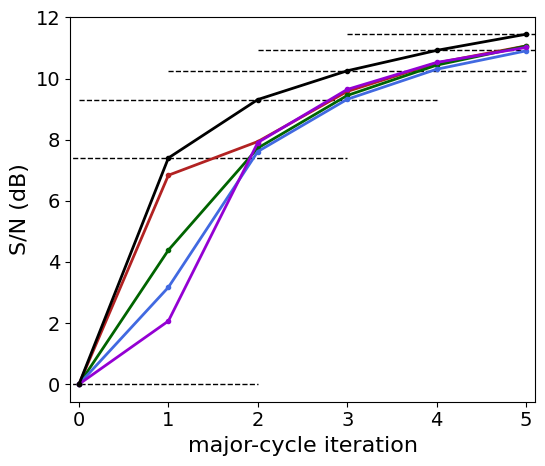

In [7]:
err = [2] * len(serialmsc_snrs)
c = plt.errorbar(range(6), serialmsc_snrs, xerr=err, c=pcols[0], label="1", lw=2, marker='o', markersize=3, elinewidth=1)
c[2][0].set_linestyle('--')
handles = [c]

for i, partition_config in enumerate(num_partitions):
    h, = plt.plot(range(6), parallelmsc_csnrs[i], c=pcols[i+1], label=str(partition_config), lw=2, marker='o', markersize=3)
    handles.append(h)
    #plt.fill_between(range(6), parallelmsc_mins[i], parallelmsc_maxes[i], edgecolor=pcols[i+1], facecolor=pcols[i+1], alpha=0.5)
#plt.plot(range(6), parallelmsc_test_csnrs, c="orange", label="10 manual", lw=2, marker='o', markersize=3)

plt.xlim(-0.1, 5.1)

#plt.legend(handles = handles, title="Nodes", loc="lower right", fontsize=14, title_fontsize=16)
plt.xlabel("major-cycle iteration", fontsize=16)
plt.ylabel("S/N (dB)", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.savefig("../figures/sgrbmsc_accuracy_bymc.png", pad_inches=0.0, bbox_inches='tight')

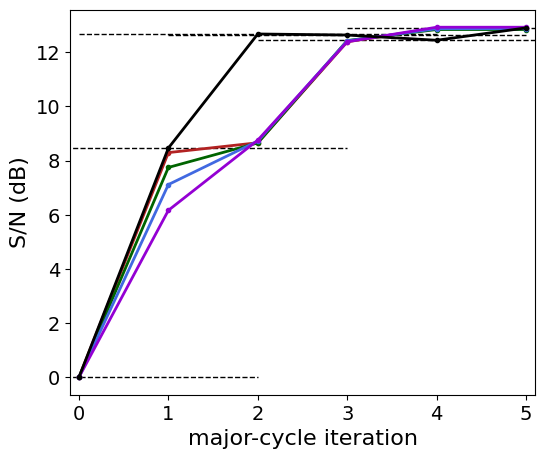

In [8]:
err = [2] * len(serialmsc_snrs)
c = plt.errorbar(range(6), seriall1_snrs, xerr=err, c=pcols[0], label="1", lw=2, marker='o', markersize=3, elinewidth=1)
c[2][0].set_linestyle('--')
handles = [c]

for i, partition_config in enumerate(num_partitions):
    h, = plt.plot(range(6), parallell1_csnrs[i], c=pcols[i+1], label=str(partition_config), lw=2, marker='o', markersize=3)
    handles.append(h)
    #plt.fill_between(range(6), parallelmsc_mins[i], parallelmsc_maxes[i], edgecolor=pcols[i+1], facecolor=pcols[i+1], alpha=0.5)

plt.xlim(-0.1, 5.1)
#plt.legend(title="Nodes", loc="lower right")
plt.xlabel("major-cycle iteration", fontsize=16)
plt.ylabel("S/N (dB)", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.savefig("../figures/sgrbl1_accuracy_bymc.png", pad_inches=0.0, bbox_inches='tight')

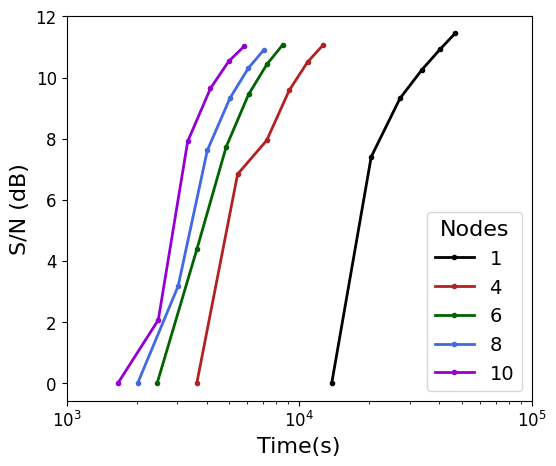

In [9]:
err = [0] * len(serialmsc_snrs)
c = plt.errorbar(serialmsc_times, serialmsc_snrs, xerr=err, c=pcols[0], label="1", lw=2, marker='o', markersize=3, elinewidth=1)
c[2][0].set_linestyle('--')
handles = [c]

for i, partition_config in enumerate(num_partitions):
    h, = plt.plot(parallelmsc_times[i], parallelmsc_csnrs[i], c=pcols[i+1], label=str(partition_config), lw=2, marker='o', markersize=3)
    handles.append(h)
    #plt.fill_between(range(6), parallelmsc_mins[i], parallelmsc_maxes[i], edgecolor=pcols[i+1], facecolor=pcols[i+1], alpha=0.5)
#plt.plot(range(6), parallelmsc_test_csnrs, c="orange", label="10 manual", lw=2, marker='o', markersize=3)

plt.legend(handles = handles, title="Nodes", loc="lower right", fontsize=14, title_fontsize=16)
plt.xlabel("Time(s)", fontsize=16)
plt.ylabel("S/N (dB)", fontsize=16)

plt.xscale("log")
plt.xticks(ticks=[0, 10, 100, 1000, 10000, 100000], fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(1000, 100000)

plt.savefig("../figures/sgramsc_accuracy_bytime.png", pad_inches=0.0, bbox_inches='tight')

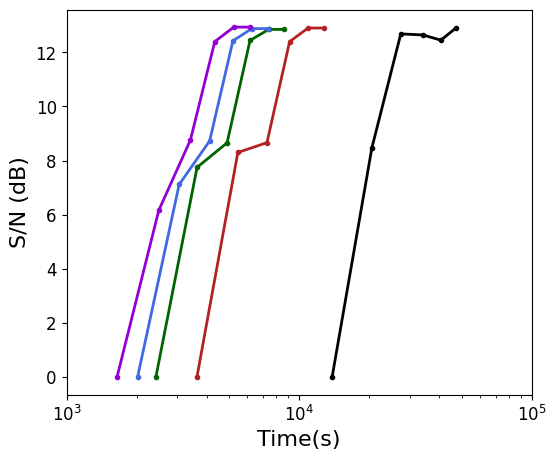

In [10]:
err = [0] * len(serialmsc_snrs)
c = plt.errorbar(seriall1_times, seriall1_snrs, xerr=err, c=pcols[0], label="1", lw=2, marker='o', markersize=3, elinewidth=1)
c[2][0].set_linestyle('--')
handles = [c]

for i, partition_config in enumerate(num_partitions):
    h, = plt.plot(parallell1_times[i], parallell1_csnrs[i], c=pcols[i+1], label=str(partition_config), lw=2, marker='o', markersize=3)
    handles.append(h)
    #plt.fill_between(range(6), parallelmsc_mins[i], parallelmsc_maxes[i], edgecolor=pcols[i+1], facecolor=pcols[i+1], alpha=0.5)

#plt.legend(title="Nodes", loc="lower right")
plt.xlabel("Time(s)", fontsize=16)
plt.ylabel("S/N (dB)", fontsize=16)

plt.xscale("log")
plt.xticks(ticks=[0, 10, 100, 1000, 10000, 100000], fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(1000, 100000)

plt.savefig("../figures/sgral1_accuracy_bytime.png", pad_inches=0.0, bbox_inches='tight')

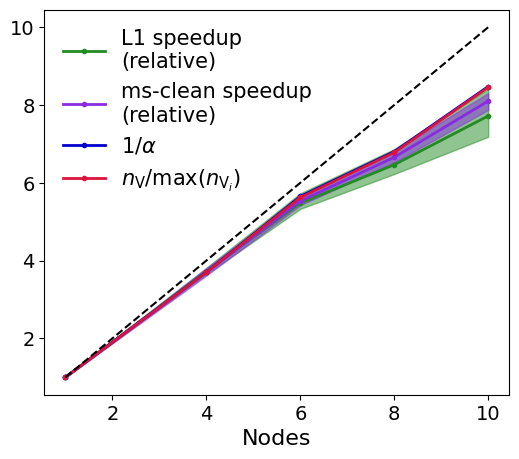

In [11]:
mcl1_times = [[1] for x in seriall1_times_bymc[0:num_mc_l1 + 1]]
mcmsc_times = [[1] for x in serialmsc_times_bymc[0:num_mc_msc + 1]]

totl1_times = [1]
totmsc_times = [1]

l1max = [1]
l1min = [1]
mscmax = [1]
mscmin = [1]

nnodes = [1] + num_partitions

cmapl1 = matplotlib.colormaps['viridis']  
colorsl1 = cmapl1(numpy.linspace(0, 0.8, num_mc_l1 + 1))

for i, partition_config in enumerate(num_partitions):
    for mc in range(num_mc_l1 + 1):
        mcl1_times[mc].append(seriall1_times_bymc[mc] / parallell1_times_bymc[i][mc])
        mcmsc_times[mc].append(serialmsc_times_bymc[mc] / parallelmsc_times_bymc[i][mc])

    totl1_times.append(seriall1_times[-1] / parallell1_times[i][-1])
    totmsc_times.append(serialmsc_times[-1] / parallelmsc_times[i][-1])

l1transpose = numpy.transpose(numpy.array(mcl1_times))
l1max = numpy.max(l1transpose, axis=1)
l1min = numpy.min(l1transpose, axis=1)
msctranspose = numpy.transpose(numpy.array(mcmsc_times))
mscmax = numpy.max(msctranspose, axis=1)
mscmin = numpy.min(msctranspose, axis=1)

for mc in range(num_mc_l1 + 1):
    lbl = str(mc) if mc > 0 else str(mc) + " (psf & weights)"
    #plt.plot(nnodes, mcl1_times[mc], c=colorsl1[mc], alpha=0.6, label=lbl, lw=2, marker='o', markersize=4)

plt.plot(nnodes, totl1_times, c="forestgreen", label=r"L1 speedup" "\n" "(relative)", lw=2, marker='o', markersize=3)
plt.fill_between(nnodes, l1min, l1max, edgecolor="forestgreen", facecolor="forestgreen", alpha=0.5)

cmapmsc = matplotlib.colormaps['inferno']  
colorsmsc = cmapmsc(numpy.linspace(0, 0.8, num_mc_msc + 1))

for mc in range(num_mc_l1 + 1):
    lbl = str(mc) if mc > 0 else str(mc) + " (psf & weights)"
    #plt.plot(nnodes, mcmsc_times[mc], c=colorsmsc[mc], alpha=1, label=lbl, lw=2, marker='o', markersize=4)

plt.plot(nnodes, totmsc_times, c="blueviolet", label=r"ms-clean speedup" "\n" "(relative)", lw=2, marker='o', markersize=3)
plt.fill_between(nnodes, mscmin, mscmax, edgecolor="blueviolet", facecolor="blueviolet", alpha=0.5)

curr_alphas = 1 / numpy.array(alphas_sgrb if config == "LOW" else alphas_sgra)
viscount_ratios = vis_counts[0] / numpy.array(vis_counts)

plt.plot(nnodes, curr_alphas, c="mediumblue", label=r"$1/\alpha$", lw=2, marker='o', markersize=3)
plt.plot(nnodes, viscount_ratios, c="crimson", label=r"$n_{\text{V}}/\text{max}(n_{\text{V}_i})$", lw=2, marker='o', markersize=3)

diag = [x + 1 for x in range(10)]

plt.plot(diag, diag, "--", c="black")

plt.legend(loc="upper left", frameon=False, fontsize=15)
#plt.ylabel("Wall-time speedup", fontsize=16)
plt.xlabel("Nodes", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.savefig("../figures/sgra_scaling.png", pad_inches=0.0, bbox_inches='tight')

## Subprocess breakdown

In [12]:
l1_breakdown_data = []
msc_breakdown_data = []

### Serial read

In [13]:
for i, lst in enumerate(seriall1_breakdown_data):
    seriall1_breakdown_data[i] = list(map(float, lst))
    
for i, lst in enumerate(serialmsc_breakdown_data):
    serialmsc_breakdown_data[i] = list(map(float, lst))

serial_l1_timings_bymc = []
serial_msc_timings_bymsc = []

serial_l1_timings_bymc.append([seriall1_breakdown_data[1][0], 0, 0, 0, sum(seriall1_breakdown_data[1][1:])])
serial_l1_timings_bymc.append([seriall1_breakdown_data[2][0], seriall1_breakdown_data[2][3], 0, 0, sum(seriall1_breakdown_data[2][1:3]) + seriall1_breakdown_data[2][4]])

serial_msc_timings_bymsc.append([serialmsc_breakdown_data[1][0], 0, 0, 0, sum(serialmsc_breakdown_data[1][1:])])
serial_msc_timings_bymsc.append([serialmsc_breakdown_data[2][0], serialmsc_breakdown_data[2][3], 0, 0, sum(serialmsc_breakdown_data[2][1:3]) + serialmsc_breakdown_data[2][4]])

for i, curr_mc_timings in enumerate(seriall1_breakdown_data[3:]):
    other_timings = sum(curr_mc_timings[1:4]) + curr_mc_timings[5] + curr_mc_timings[7]
    serial_l1_timings_bymc.append([curr_mc_timings[0], curr_mc_timings[6], curr_mc_timings[4], curr_mc_timings[8], other_timings])

for i, curr_mc_timings in enumerate(serialmsc_breakdown_data[3:]):
    other_timings = sum(curr_mc_timings[1:4]) + curr_mc_timings[5] + curr_mc_timings[7]
    serial_msc_timings_bymsc.append([curr_mc_timings[0], curr_mc_timings[6], curr_mc_timings[4], curr_mc_timings[8], other_timings])

l1_breakdown_data.append(total_timings(serial_l1_timings_bymc, breakdowns))
msc_breakdown_data.append(total_timings(serial_msc_timings_bymsc, breakdowns))

### Parallel read

In [14]:
for i, partition_config in enumerate(num_partitions):
    for node in range(partition_config):
        curr_pl1_breakdown = pl1_breakdown_data[i][node]

        for j, lst in enumerate(curr_pl1_breakdown):
            curr_pl1_breakdown[j] = list(map(float, lst))

        curr_pmsc_breakdown = pmsc_breakdown_data[i][node]

        for j, lst in enumerate(curr_pmsc_breakdown):
            curr_pmsc_breakdown[j] = list(map(float, lst))
        
        pl1_timings_bymc = []
        pmsc_timings_bymc = []

        pl1_timings_bymc.append([curr_pl1_breakdown[1][0], 0, 0, 0, 0, sum(curr_pl1_breakdown[1][1:])])
        pl1_timings_bymc.append([curr_pl1_breakdown[2][0], curr_pl1_breakdown[2][3], 0, 0, 0, sum(curr_pl1_breakdown[2][1:2]) + curr_pl1_breakdown[2][4]])
        
        pmsc_timings_bymc.append([curr_pmsc_breakdown[1][0], 0, 0, 0, 0, sum(curr_pmsc_breakdown[1][1:])])
        pmsc_timings_bymc.append([curr_pmsc_breakdown[2][0], curr_pmsc_breakdown[2][3], 0, 0, 0, sum(curr_pmsc_breakdown[2][1:2]) + curr_pmsc_breakdown[2][4]])

        for j, curr_mc_timings in enumerate(curr_pl1_breakdown[4:]):
            other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
            pl1_timings_bymc.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                            curr_mc_timings[10], other_timings])

        for j, curr_mc_timings in enumerate(curr_pmsc_breakdown[5:]):
            other_timings = sum(curr_mc_timings[1:4]) + curr_mc_timings[5] + curr_mc_timings[7]
            pmsc_timings_bymc.append([curr_mc_timings[0], curr_mc_timings[6], curr_mc_timings[4], curr_mc_timings[8], \
                            curr_mc_timings[9] + curr_mc_timings[10], other_timings])
            
        l1_breakdown_data.append(total_timings(pl1_timings_bymc, breakdowns_parallel))
        msc_breakdown_data.append(total_timings(pmsc_timings_bymc, breakdowns_parallel))

### Plot breakdown data

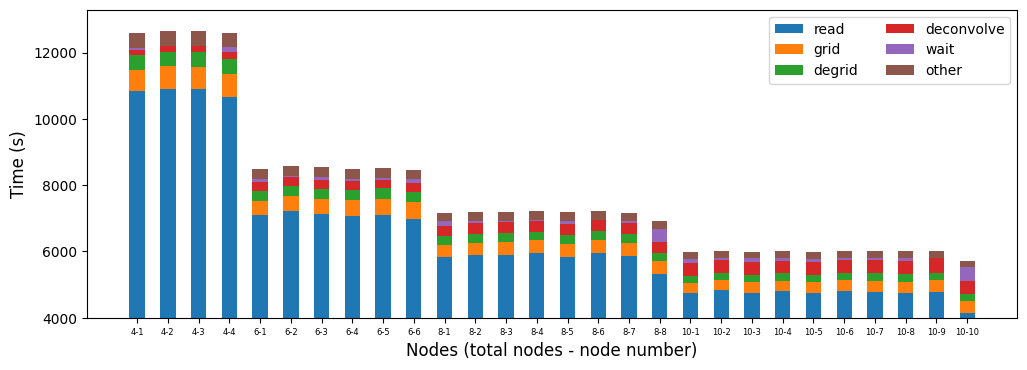

In [15]:
matplotlib.rcParams['figure.figsize'] = [12, 4]
width = 0.5

labels=["1-1"]
labels += ["4-1", "4-2", "4-3", "4-4"]
labels += ["6-1", "6-2", "6-3", "6-4", "6-5", "6-6"]
labels += ["8-1", "8-2", "8-3", "8-4", "8-5", "8-6", "8-7", "8-8"]
labels += ["10-1", "10-2", "10-3", "10-4", "10-5", "10-6", "10-7", "10-8", "10-9", "10-10"]

mask = numpy.array([False, \
                    True, True, True, True, \
                    True, True, True, True, True, True, \
                    True, True, True, True, True, True, True, True, \
                    True, True, True, True, True, True, True, True, True, True])

fig, axes = plt.subplots(1, 1)

bottom = numpy.zeros(len(labels))

for i, curr_breakdown in enumerate(breakdowns_parallel):
    curr_timings = None
    if i == 4:
        curr_timings = [0]
    elif i > 4:
        curr_timings = [l1_breakdown_data[0][i - 1]]
    else:
        curr_timings = [l1_breakdown_data[0][i]]

    for pbreakdown in l1_breakdown_data[1:]:
        curr_timings.append(pbreakdown[i])
        
    p = axes.bar(numpy.array(labels)[mask], numpy.array(curr_timings)[mask], width, label=curr_breakdown, bottom=bottom[mask])
    bottom += curr_timings

#axes.set_title('L1 deconvolution (Sgr A)', fontsize=14)
axes.legend(loc="upper right", fontsize=10, ncol=2)
axes.set_ylabel('Time (s)', fontsize=12)
axes.set_xlabel('Nodes (total nodes - node number)', fontsize=12)
axes.xaxis.set_tick_params(labelsize=6)
axes.set_ylim(bottom=4000)
    
# bottom = numpy.zeros(len(labels))

# for i, curr_breakdown in enumerate(breakdowns_parallel):
#     curr_timings = None
#     if i == 4:
#         curr_timings = [0]
#     elif i > 4:
#         curr_timings = [msc_breakdown_data[0][i - 1]]
#     else:
#         curr_timings = [msc_breakdown_data[0][i]]

#     for pbreakdown in msc_breakdown_data[1:]:
#         curr_timings.append(pbreakdown[i])
        
#     p = axes[1].bar(numpy.array(labels)[mask], numpy.array(curr_timings)[mask], width, label=curr_breakdown, bottom=bottom[mask])
#     bottom += curr_timings

# axes[1].set_title('MS-Clean deconvolution (Sgr B2)', fontsize=14)
# axes[1].legend(loc="upper right", fontsize=10, ncol=2)
# axes[1].set_ylabel('Time (s)', fontsize=12)
# axes[1].xaxis.set_tick_params(labelsize=6)

plt.savefig("../figures/l1breakdownsgra.png", pad_inches=0.0, bbox_inches='tight')

/tmp/ipykernel_3276499/3912262588.py:42: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes.set_ylim(bottom=0, top=5e5)


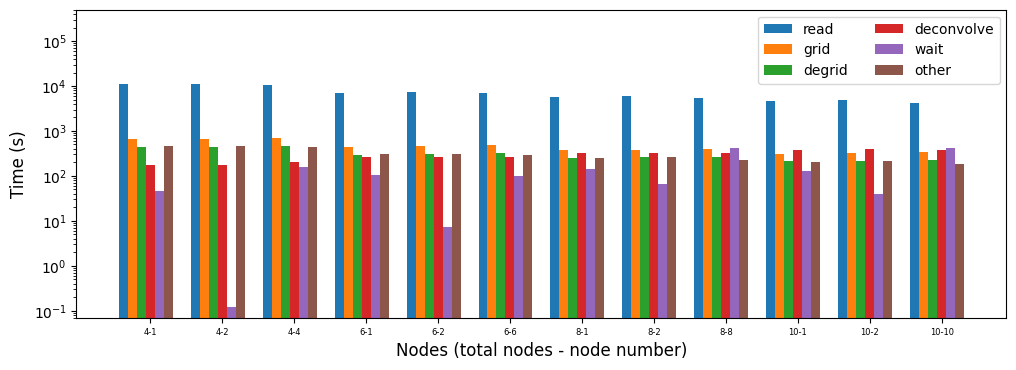

In [16]:
matplotlib.rcParams['figure.figsize'] = [12, 4]
width = 1/8

labels=["1-1"]
labels += ["4-1", "4-2", "4-3", "4-4"]
labels += ["6-1", "6-2", "6-3", "6-4", "6-5", "6-6"]
labels += ["8-1", "8-2", "8-3", "8-4", "8-5", "8-6", "8-7", "8-8"]
labels += ["10-1", "10-2", "10-3", "10-4", "10-5", "10-6", "10-7", "10-8", "10-9", "10-10"]

mask = numpy.array([False, \
                    True, True, False, True, \
                    True, True, False, False, False, True, \
                    True, True, False, False, False, False, False, True, \
                    True, True, False, False, False, False, False, False, False, True])

fig, axes = plt.subplots(1, 1)

x = numpy.arange(numpy.sum(mask))

for i, curr_breakdown in enumerate(breakdowns_parallel):
    curr_timings = None
    if i == 4:
        curr_timings = [0]
    elif i > 4:
        curr_timings = [l1_breakdown_data[0][i - 1]]
    else:
        curr_timings = [l1_breakdown_data[0][i]]

    for pbreakdown in l1_breakdown_data[1:]:
        curr_timings.append(pbreakdown[i])
    
    p = axes.bar(x + (i - 3) * width, numpy.array(curr_timings)[mask], width, label=curr_breakdown)

#axes.set_title('L1 deconvolution (Sgr A)', fontsize=14)
axes.legend(loc="upper right", fontsize=10, ncol=2)
axes.set_ylabel('Time (s)', fontsize=12)
axes.set_xlabel('Nodes (total nodes - node number)', fontsize=12)
axes.set_xticks(x)
axes.set_xticklabels(numpy.array(labels)[mask])
axes.xaxis.set_tick_params(labelsize=6)
axes.set_yscale('log')
axes.set_ylim(bottom=0, top=5e5)


plt.savefig("../figures/l1breakdownsgra2.pdf", pad_inches=0.0, bbox_inches='tight')

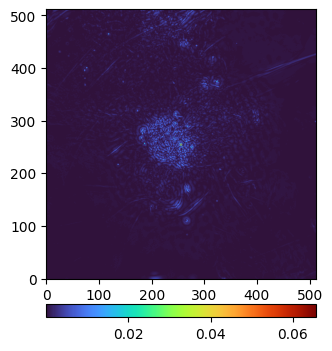

In [17]:
recon_dec = util.fromfits(results_root + config + "/10/pmsc/recon_combined_4.fits")
recon_ser = util.fromfits(results_root + config + "/10/msc/final_deconvolved.fits")
dec_err = numpy.abs(recon_dec - gt)
ser_err = numpy.abs(recon_ser - gt)

util.plotNImages([ser_err], [""], cmap=cmap, same_scale=True, additional_scale_imgs=[dec_err], output_file="../figures/serr_err.pdf")


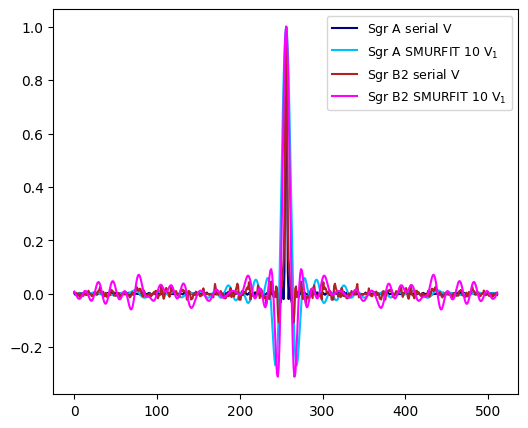

In [18]:
matplotlib.rcParams['figure.figsize'] = [6, 5]

sgraser_psf = util.fromfits(results_root + "MID/10/msc/psf.fits")
sgra10_psf = util.fromfits(results_root + "MID/10/pmsc/psf_1.fits")

sgrbser_psf = util.fromfits(results_root + "LOW/10/msc/psf.fits")
sgrb10_psf = util.fromfits(results_root + "LOW/10/pmsc/psf_1.fits")


plt.plot(sgraser_psf[256,:], c = "navy", label=r"Sgr A serial $\text{V}$")
plt.plot(sgra10_psf[256,:], c = "deepskyblue", label=r"Sgr A SMURFIT 10 $\text{V}_1$")
plt.plot(sgrbser_psf[256,:], c = "firebrick", label=r"Sgr B2 serial $\text{V}$")
plt.plot(sgrb10_psf[256,:], c = "fuchsia", label=r"Sgr B2 SMURFIT 10 $\text{V}_1$")

plt.legend(loc="upper right", fontsize=9)

plt.savefig("../figures/psflobes.png", pad_inches=0.0, bbox_inches='tight')

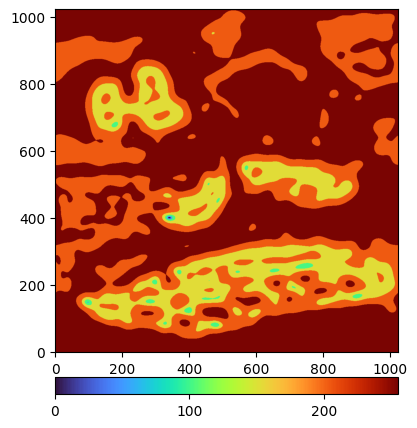

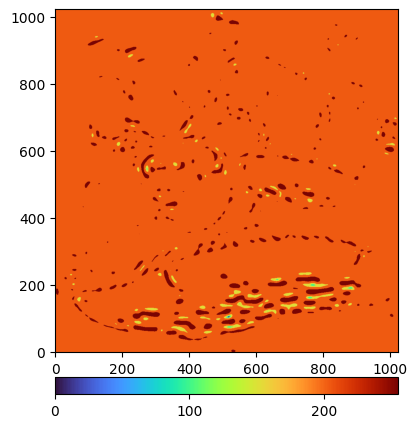

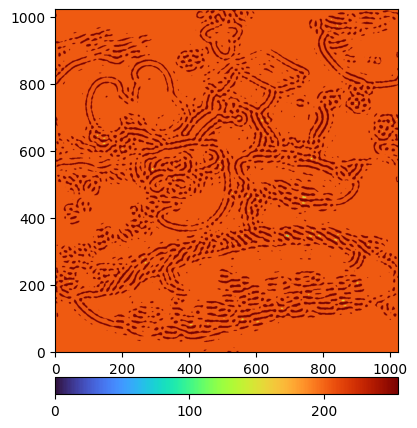

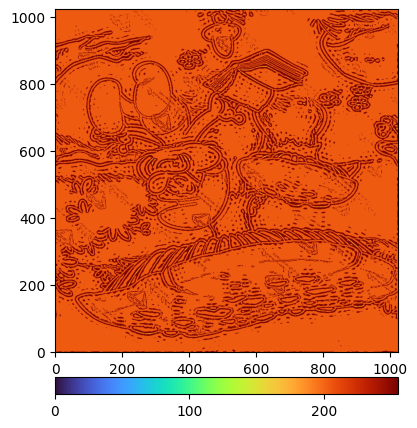

In [51]:
from PIL import Image
from radioimaging.images import filters

im_frame = Image.open("/home/sunwang/smurfs.png")
papsmurf = numpy.array(im_frame.getdata())
papsmurf = papsmurf.reshape((1067, 1200, 4))
midx = 1067 // 2
midy = 1200 // 2
hw = 512

papsmurf = papsmurf[midx-hw:midx+hw, midy-hw:midy+hw,:]

delta = 1
ells = [20, 50, 80]
sigma2s = [1, 1, 1, 1]

frs, _, _ = filters.create_filters_mstep(512, [delta]*len(ells), ells, sigma2s)
frns = [numpy.array(fr) for fr in frs]
fs2ds = [filters.freq1d_to_radial2d(f1d, 1024)[1] for f1d in frns]

for i, f in enumerate(fs2ds):
    filtered = papsmurf.copy()
    
    for j in range(3):
        filtered[:,:,j] = util.convolve2d(papsmurf[:,:,j], f)#util.image_histogram_equalization(util.convolve2d(papsmurf[:,:,j], f), number_bins=256)

        minval = numpy.min(util.convolve2d(papsmurf[:,:,j], f))
        maxval = numpy.max(util.convolve2d(papsmurf[:,:,j], f))
        
        norm_factor = 255 / (maxval - minval)

        filtered[:,:,j] = numpy.log(((filtered[:,:,j] - minval) * norm_factor).astype(filtered.dtype) + 1)
        filtered[:,:,j] = (filtered[:,:,j] * (255 / numpy.max(filtered[:,:,j]))).astype(filtered.dtype)
    
    util.plotNImages([filtered[:,:,1]], [""], cmap=cmap)
    
    img = Image.fromarray(filtered.astype(numpy.uint8))
    img.save('filt' + str(i) + '.png')